<H1 style="text-align:center; font-weight:bold; text-transform: capitalize">analyse rentabilite cycliste-Cyclistic(entreprise)</H1><br>
<h3 style="text-transform:uppercase">contexte</h3>
<p> Dans une ville au etat unis, une societe de cycliste aimerai augmente d'avantage les adhesions d'abonnement mensuel et annuel pour les stationnements des cyclistes. nous avons remarquer que certain cycliste paie de maniere occasionnelle et aimerons leur pousser ou leur prouver qu'il serait judicieux et adequat pour eux de s'abonner a la societe (compte tenu du trajet et tout le decombre). L'entreprise est prette a faire le necessaire pour acquerir des gens et s'etendre aussi.</p><br>
<h3 style="font-weight:bold">OBJECTIF:</h3>
<p>Sur la base des donnees que nous avons:</p>
<ol>
    <li>evaluer la repartion des categories de velo selon les categories de personne(membre ou casual)</li>
    <li>determiner la repartition des membres et des casuals aucour du mois et saison</li>
    <li>determiner la repartition des categorie de velo aucour des differents mois.</li>
    <li>determiner les parcours les plus utiliser aucours de chaque saison chez les membres et les casuals</li>
    <li>determiner les parcours les plus utiliser aucour de chaque mois avec les proportions d'utilisation des membres et des casuals</li>
    <li>evaluer l'impact de la categorie de velo sur les meilleurs parcours aucours de la saison(savoir s'il ont un impact l'un sur l'autre)</li>
    <li>evaluer l'impact de la categorie de velo sur les meilleurs parcours aucours du mois(savoir s'il ont un impact l'un sur l'autre)</li>
    <li>evaluer les distances parcouru par chaque categorie de velo aucour des meilleurs parcours de chaque:
        <ul>
            <li>saison</li>
            <li>mois</li>
            <li>annee</li>
        </ul>
    </li>
    <li>rechercher les infos sur la temperature qu'il fesait a chaque periode.</li>
</ol>
<p>Dans un premier temps ; commencons par importer deja l'ensemble des donnees et essayons de les harmoniser (car dans mon cas, jai 12 dataset qui correspondent a ensemble de mes donnees durant chaque mois d'une annee</P>
<h4 style="font_weight:bold; text-align:center">1. IMPORTATION ET SYNCHRONISATION DE NOS DATASETS</h4>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob

In [43]:
## recuperation du dossier possedant lensemble des donnees du cycliste
dossier=glob.glob("cycliste/*csv")

## recuperation et concatenation des differentes dataset
df=pd.concat((pd.read_csv(fichier) for fichier in dossier), ignore_index=True)

df.head()

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual
0,F96D5A74A3E41399,electric_bike,2023-01-21 20:05:42,2023-01-21 20:16:33,Lincoln Ave & Fullerton Ave,TA1309000058,Hampden Ct & Diversey Ave,202480.0,41.924074,-87.646278,41.930000,-87.640000,member
1,13CB7EB698CEDB88,classic_bike,2023-01-10 15:37:36,2023-01-10 15:46:05,Kimbark Ave & 53rd St,TA1309000037,Greenwood Ave & 47th St,TA1308000002,41.799568,-87.594747,41.809835,-87.599383,member
2,BD88A2E670661CE5,electric_bike,2023-01-02 07:51:57,2023-01-02 08:05:11,Western Ave & Lunt Ave,RP-005,Valli Produce - Evanston Plaza,599,42.008571,-87.690483,42.039742,-87.699413,casual
3,C90792D034FED968,classic_bike,2023-01-22 10:52:58,2023-01-22 11:01:44,Kimbark Ave & 53rd St,TA1309000037,Greenwood Ave & 47th St,TA1308000002,41.799568,-87.594747,41.809835,-87.599383,member
4,3397017529188E8A,classic_bike,2023-01-12 13:58:01,2023-01-12 14:13:20,Kimbark Ave & 53rd St,TA1309000037,Greenwood Ave & 47th St,TA1308000002,41.799568,-87.594747,41.809835,-87.599383,member


In [44]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
start_lat,5719877.0,41.902885,0.045056,41.63,41.880958,41.899019,41.930000,42.07
start_lng,5719877.0,-87.647036,0.027334,-87.94,-87.660000,-87.644031,-87.629912,-87.46
end_lat,5712887.0,41.903221,0.054444,0.00,41.881032,41.900000,41.930000,42.18
end_lng,5712887.0,-87.647203,0.069196,-88.16,-87.660274,-87.644098,-87.630000,0.00


<p>evaluation des valeurs manquantes</p>

In [47]:
df.isnull().sum()

ride_id                    0
rideable_type              0
started_at                 0
ended_at                   0
start_station_name    875716
start_station_id      875848
end_station_name      929202
end_station_id        929343
start_lat                  0
start_lng                  0
end_lat                 6990
end_lng                 6990
member_casual              0
dtype: int64

In [49]:
df.dropna(subset="start_station_id", inplace=True)
df.dropna(subset="end_station_id", inplace=True)
df.dropna(subset="end_lat", inplace=True)

df.isnull().sum()

ride_id               0
rideable_type         0
started_at            0
ended_at              0
start_station_name    0
start_station_id      0
end_station_name      0
end_station_id        0
start_lat             0
start_lng             0
end_lat               0
end_lng               0
member_casual         0
dtype: int64

In [21]:
#liste=df["start_lat"].unique().tolist()
#for row in df_null:
#def remplissage(row):
#    test=df[(df["start_lat"]==row["start_lat"]) & (df["start_lng"]==row["start_lng"])]
#    row["start_station_id"]=model(test,"start_station_id")
#
#df_clean=df_null.apply(remplissage)
#df_clean.isnull().sum()

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4331707 entries, 0 to 5719876
Data columns (total 13 columns):
 #   Column              Dtype  
---  ------              -----  
 0   ride_id             object 
 1   rideable_type       object 
 2   started_at          object 
 3   ended_at            object 
 4   start_station_name  object 
 5   start_station_id    object 
 6   end_station_name    object 
 7   end_station_id      object 
 8   start_lat           float64
 9   start_lng           float64
 10  end_lat             float64
 11  end_lng             float64
 12  member_casual       object 
dtypes: float64(4), object(9)
memory usage: 462.7+ MB


<p style="font-size:30px">reconversion du format objet en format date de la colonne "started_at" et "ended_at"</p>

In [53]:
df["started_at"]=pd.to_datetime(df["started_at"], format="%Y-%m-%d %H:%M:%S")
df["ended_at"]=pd.to_datetime(df["ended_at"], format="%Y-%m-%d %H:%M:%S")

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4331707 entries, 0 to 5719876
Data columns (total 13 columns):
 #   Column              Dtype         
---  ------              -----         
 0   ride_id             object        
 1   rideable_type       object        
 2   started_at          datetime64[ns]
 3   ended_at            datetime64[ns]
 4   start_station_name  object        
 5   start_station_id    object        
 6   end_station_name    object        
 7   end_station_id      object        
 8   start_lat           float64       
 9   start_lng           float64       
 10  end_lat             float64       
 11  end_lng             float64       
 12  member_casual       object        
dtypes: datetime64[ns](2), float64(4), object(7)
memory usage: 462.7+ MB


<p style="font-size:30px">filtrage de ligne, pour ne considerer que celle ayant une date d'arrivee superieur a celle de depart</p>

In [55]:
df=df[df["started_at"]<df["ended_at"]]
df.shape

(4331138, 13)

In [57]:
dr=df["end_station_id"].unique().tolist()
len(dr)

1483

In [59]:
unic=df.groupby(["end_station_id","end_station_name"]).agg(total_intervention=("end_station_name","count")).reset_index().sort_values(by="total_intervention",ascending=False)
unic["end_station_name"].unique().size

1557

In [63]:
cont=[]
dupl=[]#unic["end_station_id"].tolist()
for col in unic["end_station_id"]:
    #print(col)
    if col in cont:
        dupl.append(col)
    else:
        cont.append(col)

len(dupl)

84

In [65]:
def mode(df,var):
    dict={}
    val=df[var].unique()
    val.tolist()
    for v in val:
        nbre=0
        for i in range(len(df)):
            if df[var].iloc[i]==v:
                nbre=nbre+1
        dict[v]=nbre
    max=next(iter(dict.keys()))
    for keys in dict:
        if dict[max]<dict[keys]:
            max=keys
    return max

In [67]:
for col in dupl:
    d=df[df["end_station_id"]==col]
    mod=mode(d,"end_station_id")
    df.loc[df["end_station_id"]==col, "end_station_name"]=mod


In [69]:
df["end_station_name"].unique().size

1475

In [71]:
def saison(mois):
    if mois in [12,1,2]:
        return "Hiver"
    elif mois in [3,4,5]:
        return "Printemps"
    elif mois in [6,7,8]:
        return "Ete"
    else:
        return "Automne"


df["mois"]=df["started_at"].dt.month
df["jour"]=df["started_at"].dt.day_name()
df["saison"]=df["mois"].apply(saison)
df["duree"]=df["ended_at"]-df["started_at"]
#convertir
df["duree_trajet"]=df["duree"].apply(lambda x:(pd.Timestamp("1900-01-01")+x).time())
df["duree_second"]=df["duree_trajet"].apply(lambda x: x.hour*3600 + x.minute*60 + x.second if pd.notnull(x) else None)

df

,ride_id,rideable_type,started_at,ended_at,start_station_name,start_station_id,end_station_name,end_station_id,start_lat,start_lng,end_lat,end_lng,member_casual,mois,jour,saison,duree,duree_trajet,duree_second
0,F96D5A74A3E41399,electric_bike,2023-01-21 20:05:42,2023-01-21 20:16:33,Lincoln Ave & Fullerton Ave,TA1309000058,Hampden Ct & Diversey Ave,202480.0,41.924074,-87.646278,41.930000,-87.640000,member,1,Saturday,Hiver,0 days 00:10:51,00:10:51,651
1,13CB7EB698CEDB88,classic_bike,2023-01-10 15:37:36,2023-01-10 15:46:05,Kimbark Ave & 53rd St,TA1309000037,Greenwood Ave & 47th St,TA1308000002,41.799568,-87.594747,41.809835,-87.599383,member,1,Tuesday,Hiver,0 days 00:08:29,00:08:29,509
2,BD88A2E670661CE5,electric_bike,2023-01-02 07:51:57,2023-01-02 08:05:11,Western Ave & Lunt Ave,RP-005,Valli Produce - Evanston Plaza,599,42.008571,-87.690483,42.039742,-87.699413,casual,1,Monday,Hiver,0 days 00:13:14,00:13:14,794
3,C90792D034FED968,classic_bike,2023-01-22 10:52:58,2023-01-22 11:01:44,Kimbark Ave & 53rd St,TA1309000037,Greenwood Ave & 47th St,TA1308000002,41.799568,-87.594747,41.809835,-87.599383,member,1,Sunday,Hiver,0 days 00:08:46,00:08:46,526
4,3397017529188E8A,classic_bike,2023-01-12 13:58:01,2023-01-12 14:13:20,Kimbark Ave & 53rd St,TA1309000037,Greenwood Ave & 47th St,TA1308000002,41.799568,-87.594747,41.809835,-87.599383,member,1,Thursday,Hiver,0 days 00:15:19,00:15:19,919
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5719872,F74DF9549B504A6B,electric_bike,2023-12-07 13:15:24,2023-12-07 13:17:37,900 W Harrison St,13028,Racine Ave & Congress Pkwy,TA1306000025,41.874702,-87.649804,41.874640,-87.657030,casual,12,Thursday,Hiver,0 days 00:02:13,00:02:13,133
5719873,BCDA66E761CC1029,classic_bike,2023-12-08 18:42:21,2023-12-08 18:45:56,900 W Harrison St,13028,Racine Ave & Congress Pkwy,TA1306000025,41.874754,-87.649807,41.874640,-87.657030,casual,12,Friday,Hiver,0 days 00:03:35,00:03:35,215
5719874,D2CF330F9C266683,classic_bike,2023-12-05 14:09:11,2023-12-05 14:13:01,900 W Harrison St,13028,Racine Ave & Congress Pkwy,TA1306000025,41.874754,-87.649807,41.874640,-87.657030,member,12,Tuesday,Hiver,0 days 00:03:50,00:03:50,230
5719875,3829A0D1E00EE970,electric_bike,2023-12-02 21:36:07,2023-12-02 21:53:45,Damen Ave & Madison St,13134,Morgan St & Lake St*,chargingstx4,41.881396,-87.674984,41.885492,-87.652289,casual,12,Saturday,Hiver,0 days 00:17:38,00:17:38,1058


<h1 style="text-align:center; font-weight:bold; text-transform: capitalize">analyse exploratoire</h1>

<p style=" font-size:25px"> 1. Evaluation de la repartition de categorie de velo au differente categorie de personne</p>

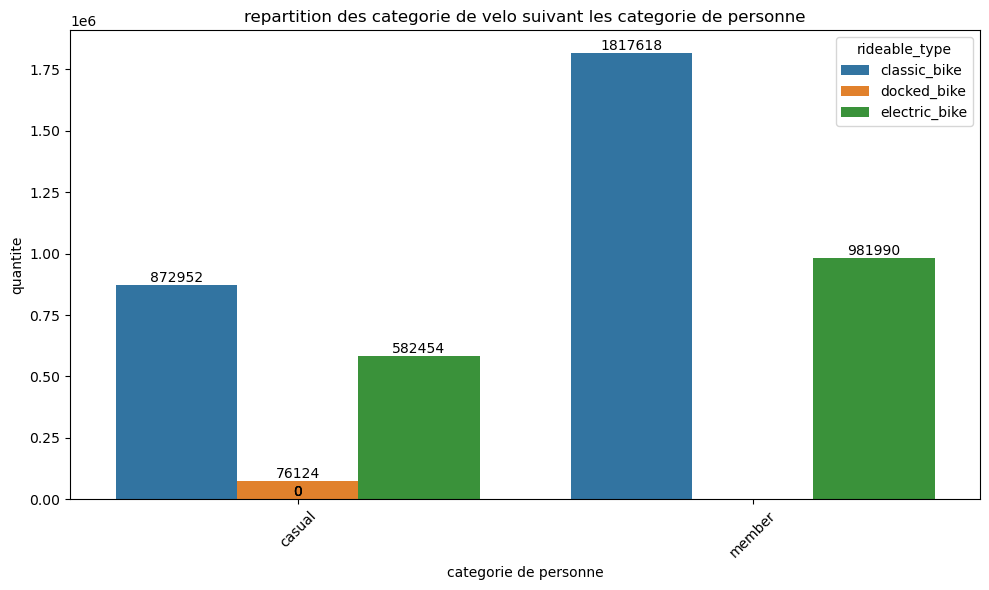

In [73]:
d=df.groupby(["member_casual","rideable_type"]).agg(total=("rideable_type","count"))

plt.figure(figsize=(10,6))
bars=sns.barplot(x="member_casual",y="total",hue="rideable_type", data=d)

for b in bars.patches:
    bars.annotate(format(b.get_height(), ".0f"), ( b.get_x() + b.get_width() / 2. ,b.get_height()), ha="center", va="bottom")


plt.title("repartition des categorie de velo suivant les categorie de personne")
plt.xlabel("categorie de personne")
plt.ylabel("quantite")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

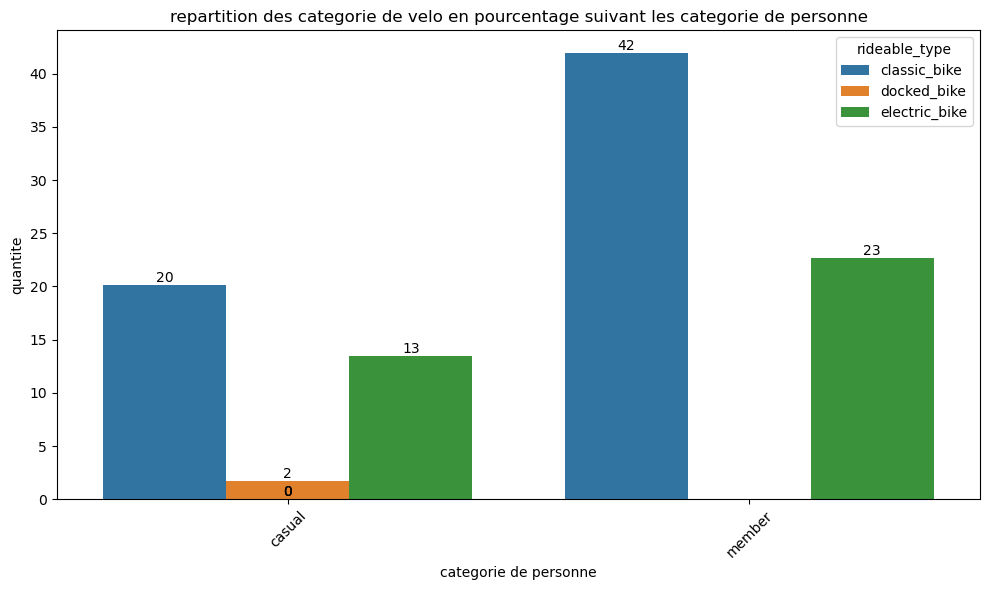

In [39]:
d=df.groupby(["member_casual","rideable_type"]).agg(total=("rideable_type","count"))
t=len(df)
d["valeur_x_en_%"]=(d["total"]/t)*100

plt.figure(figsize=(10,6))
bars=sns.barplot(x="member_casual",y="valeur_x_en_%",hue="rideable_type", data=d)

for b in bars.patches:
    bars.annotate(format(b.get_height(), ".0f"), ( b.get_x() + b.get_width() / 2. ,b.get_height()), ha="center", va="bottom")


plt.title("repartition des categorie de velo en pourcentage suivant les categorie de personne")
plt.xlabel("categorie de personne")
plt.ylabel("quantite")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<p style="font-weight:bold;font-size:25px">Evaluation du trafic aucour de l'annee par mois</p>

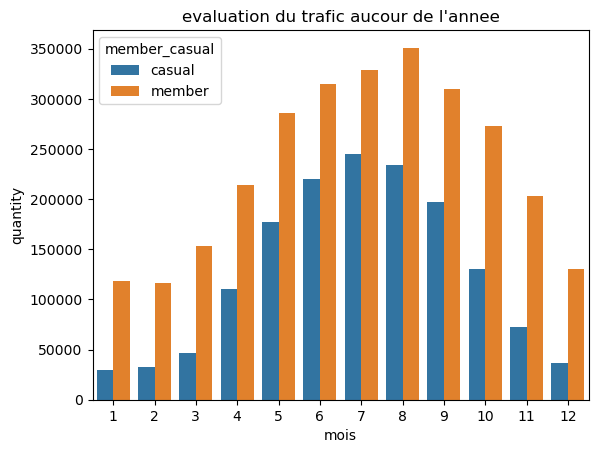

In [37]:
de=df.groupby(["saison","mois","member_casual"]).agg(total=("member_casual","count")).reset_index()

sns.barplot(x="mois", y="total", hue="member_casual", data=de)
plt.title("evaluation du trafic aucour de l'annee")
plt.xlabel("mois")
plt.ylabel("quantity")
plt.show()

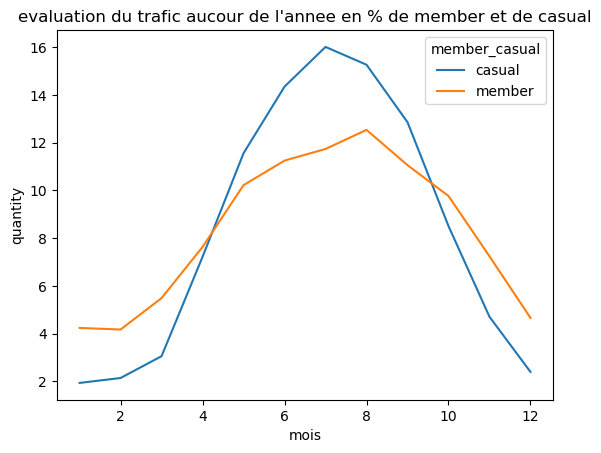

In [39]:
t_m=len(df[df["member_casual"]=="member"])
t_c=len(df[df["member_casual"]=="casual"])

def pour(row):
    if row["member_casual"]=="member":
        return (row["total"]/t_m)*100
    else:
        return (row["total"]/t_c)*100

#de=df.groupby(["saison","mois","member_casual"]).agg(total=("member_casual","count")).reset_index()

de["val_x_en_%"]=de.apply(pour,axis=1)

sns.lineplot(x="mois", y="val_x_en_%", hue="member_casual", data=de)
plt.title("evaluation du trafic aucour de l'annee en % de member et de casual")
plt.xlabel("mois")
plt.ylabel("quantity")
plt.show()

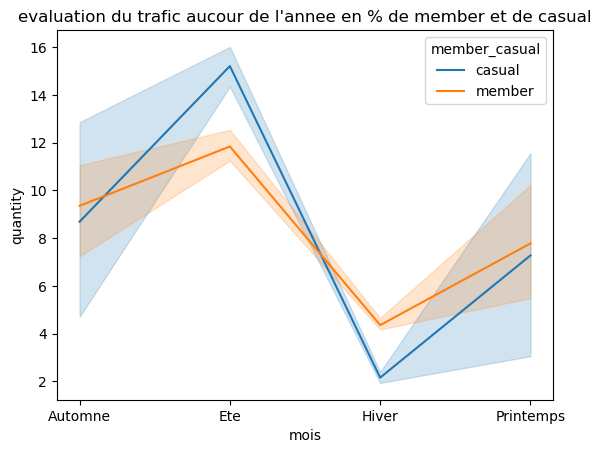

In [41]:
t_m=len(df[df["member_casual"]=="member"])
t_c=len(df[df["member_casual"]=="casual"])

def pour(row):
    if row["member_casual"]=="member":
        return (row["total"]/t_m)*100
    else:
        return (row["total"]/t_c)*100

de=df.groupby(["saison","mois","member_casual"]).agg(total=("member_casual","count")).reset_index()

de["val_x_en_%"]=de.apply(pour,axis=1)

sns.lineplot(x="saison", y="val_x_en_%", hue="member_casual", data=de)
plt.title("evaluation du trafic aucour de l'annee en % de member et de casual")
plt.xlabel("mois")
plt.ylabel("quantity")
plt.show()

<h3 style="font-size:25px; font-weight:bold">repartition des categories de velo aucour de l'annee</h3>

In [43]:
def barp(df,tab,situation):
    #last=tab[-1]
    ta=tab.pop(-1)
    de=df.groupby(tab).agg(total=(ta,"count")).reset_index()
    de.loc[:,"membre_casual"]=situation
    if de.loc[1,"membre_casual"]=="member":
        de["valeur"]=  (de["total"]/t_m)*100 
    else:
        de["valeur"]= (de["total"]/t_c)*100
    
    sns.barplot(x=tab[1], y="valeur", hue=tab[-1], data=de)
    plt.title("evaluation du trafic aucour de l'annee")
    plt.xlabel(tab[1])
    plt.ylabel("quantity")
    return plt.show()

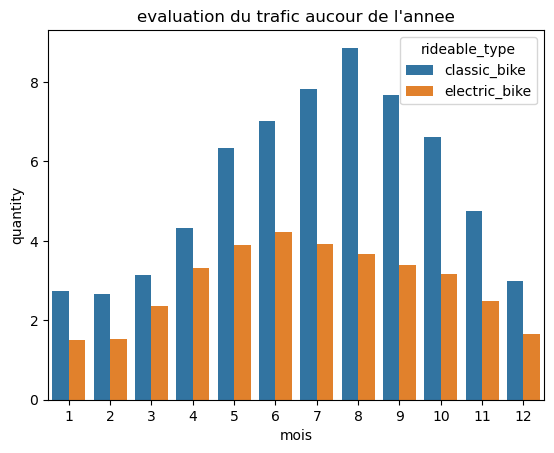

In [45]:
etude=["saison","mois","rideable_type","rideable_type"]
df_cas=df[df["member_casual"]=="casual"]
df_mem=df[df["member_casual"]=="member"]


barp(df_mem,etude,"member")

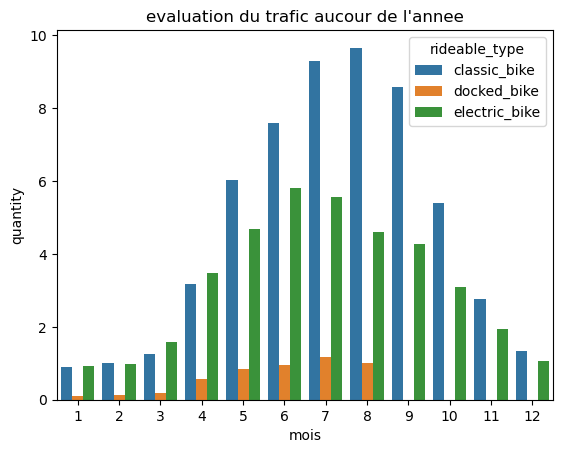

In [47]:
etude=["saison","mois","rideable_type","rideable_type"]
barp(df_cas,etude,"casual")

<h3 style="font-size:25px; font-weight:bold">Etude des parcours les plus utiliser entre les members et les casual </h3>

In [37]:
a=len(df[df["member_casual"]=="member"])
b=len(df[df["member_casual"]=="casual"])

def nbre_cas(row):
    a=df[(df["start_station_name"]==row["start_station_name"]) & (df["end_station_name"]==row["end_station_name"]) & (df["saison"]==row["saison"]) & (df["member_casual"]=="casual")]
    return len(a)

def nbre_mem(row):
    a=df[(df["start_station_name"]==row["start_station_name"]) & (df["end_station_name"]==row["end_station_name"]) & (df["saison"]==row["saison"]) & (df["member_casual"]=="member")]
    return len(a)

def parcou(df,saison):
    dfe=df[df["saison"]==saison]
    dsf=dfe.groupby(["start_station_name","end_station_name","saison"]).agg(intervention=("start_station_id","count"),duree_moyen=("duree_second","mean")).reset_index().sort_values(by="intervention",ascending=False)
    
    dsf["trajet"]=dsf["start_station_name"]+" -- "+dsf["end_station_name"]
    dsf["minute"]=pd.to_datetime(dsf["duree_moyen"], unit='s').dt.strftime("%H:%M:%S")
    dsf["int_casual"]=dsf.apply(nbre_cas,axis=1)
    dsf["freq_cas"]=(dsf[int_casual]/b)*100
    dsf["int_member"]=dsf.apply(nbre_mem,axis=1)
    dsf["freq_mem"]=(dsf[int_member]/b)*100
    ds=dsf.loc[:,["trajet","intervention","duree_moyen","freq_mem","freq_cas"]]
    #ds=dsf.melt(id_var=["trajet","intervention","duree_moyen"], value_vars=["freq_mem","freq_cas"], var_name="frequence", value_name="count")
    return ds.head(10)

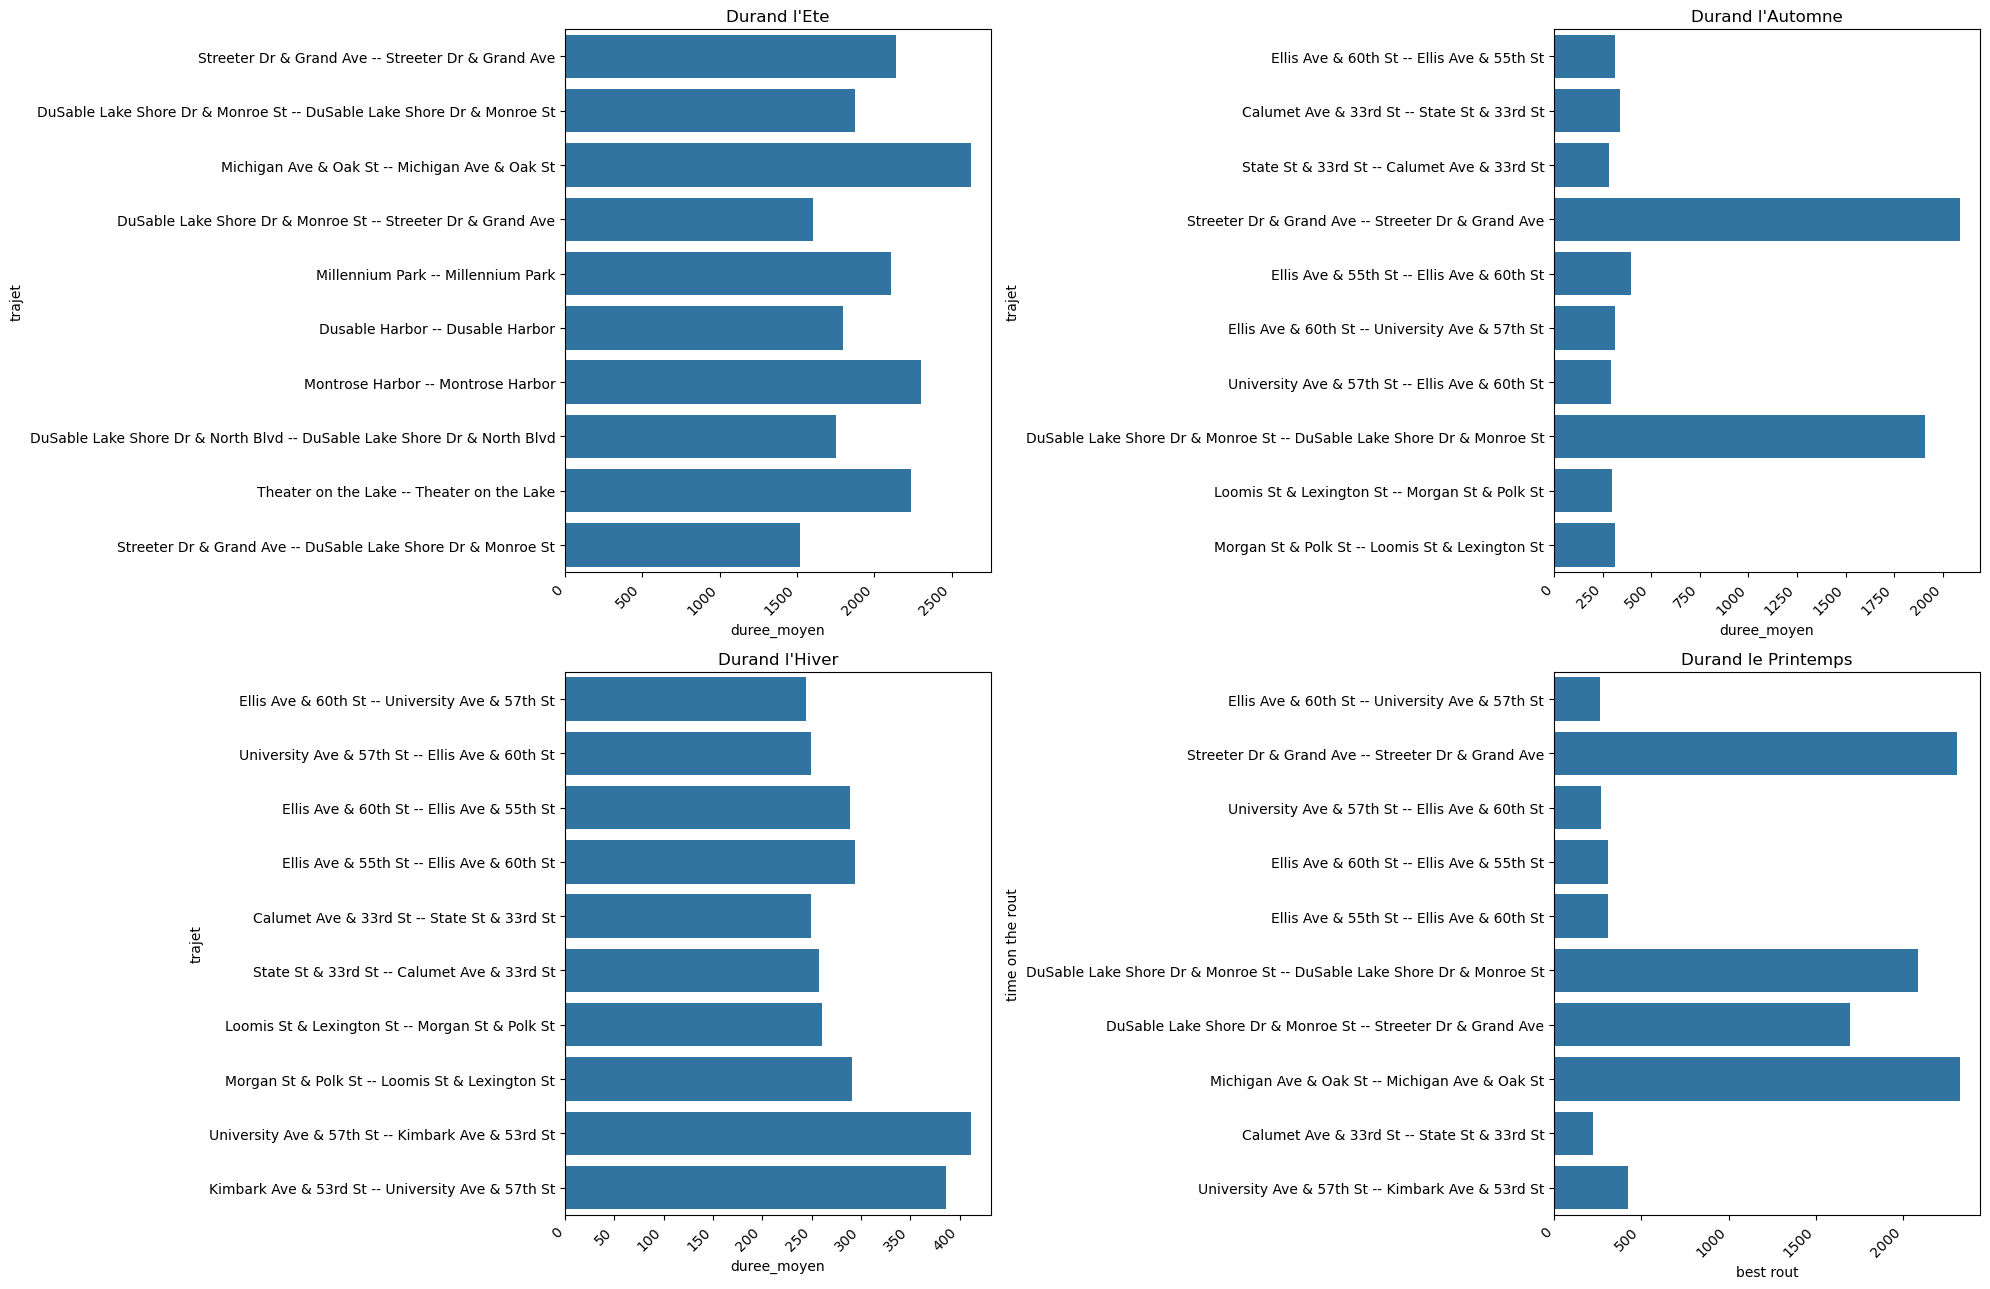

In [45]:
for i,saison in enumerate(df['saison'].unique()):
    if saison=="Printemps":
        printemp=parcou(df,saison)
    elif saison=="Automne":
        automne=parcou(df,saison)
    elif saison=="Hiver":
        hiver=parcou(df,saison)
    else:
        ete=parcou(df,saison)





plt.figure(figsize=(20,13))
plt.subplot(2,2,1)
plt.title("Durand l'Ete")
bar=sns.barplot(x='duree_moyen', y='trajet', dodge=True, data=ete)
plt.xticks(rotation=45, ha='right')
plt.subplot(2,2,2)
plt.title("Durand l'Automne")
bar=sns.barplot(x='duree_moyen', y='trajet', dodge=True, data=automne)
plt.xticks(rotation=45, ha='right')
plt.subplot(2,2,3)
plt.title("Durand l'Hiver")
bar=sns.barplot(x='duree_moyen', y='trajet', dodge=True, data=hiver)
plt.xticks(rotation=45, ha='right')
plt.subplot(2,2,4)
plt.title("Durand le Printemps")
bar=sns.barplot(x='duree_moyen', y='trajet', dodge=True, data=printemp)
plt.xticks(rotation=45, ha='right')


plt.xlabel("best rout")
plt.ylabel("time on the rout")
plt.tight_layout()
plt.show()    

In [ ]:
vb=parcou(df,"Ete")
va=vb.melt(id_var=["trajet","intervention","duree_moyen"], value_vars=["freq_mem","freq_cas"], var_name="frequence", value_name="count")
va

In [1]:
va

NameError: name 'va' is not defined